# Lab 1B — Fuzzy Q-Learning for CartPole Balancing

**Aim:** Design and implement a Fuzzy Q-Learning (FQL) agent that learns to balance
a pole in the `CartPole-v1` environment by combining a fuzzy state representation
with Q-learning.

**Reference:** [seyedsaeidmasoumzadeh/Fuzzy-Q-Learning](https://github.com/seyedsaeidmasoumzadeh/Fuzzy-Q-Learning)
— a Python implementation of Jouffe's (1998) Fuzzy Q-Learning algorithm. We follow
the same core idea (fuzzy rules, each holding its own little Q-table, blended by
firing strength) adapted to Gymnasium's `CartPole-v1`, which has a **discrete**
2-action space (push left / push right) rather than the continuous force output
that repo's example uses.

**What this notebook covers, task by task:**
1. Fuzzify the 4 continuous CartPole state variables into linguistic terms (2 and 5 fuzzy sets)
2. Construct fuzzy rules from those terms
3. Apply Q-learning on top of the fuzzy rules
4. Use an ε-greedy policy for action selection
5. Compare **triangular** vs **trapezoidal** membership functions
6. Compare learning rate **α = 0.01, 0.05, 0.1**
7. Compare discount factor **γ = 0.5, 0.9**


## 0. Setup

A quick note on methodology before we start: tasks 1, 5, 6 and 7 each ask for a
comparison along *one* axis (set count, membership shape, learning rate, discount
factor). Testing every combination of all four would mean 2×2×3×2 = 24 full
training runs. Instead we train **one shared baseline** (5 fuzzy sets, triangular,
α = 0.1, γ = 0.9) and vary a single factor at a time against it — six training runs
in total, each one directly answering one of the questions above.


In [2]:
%%capture
%pip install -q "gymnasium[classic-control]" pandas


In [3]:
import os, tempfile

os.environ.setdefault("SDL_AUDIODRIVER", "dummy")
os.environ.setdefault("PYGAME_HIDE_SUPPORT_PROMPT", "1")
os.environ.setdefault("XDG_RUNTIME_DIR", tempfile.mkdtemp())

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import product
import gymnasium as gym

RNG_SEED = 42
np.random.seed(RNG_SEED)
print("Gymnasium version:", gym.__version__)


Gymnasium version: 1.3.0


## 1. Meet the environment

`CartPole-v1` gives 4 continuous readings every step:

| Variable | Meaning | Episode ends if |
|---|---|---|
| $x_1$ | Cart position | $\lvert x_1 \rvert > 2.4$ |
| $x_2$ | Cart velocity | — |
| $x_3$ | Pole angle | $\lvert x_3 \rvert > 0.209$ rad (≈12°) |
| $x_4$ | Pole angular velocity | — |

There are only **2 actions** — push the cart left (`0`) or right (`1`) — and the
reward is `+1` for every step the pole stays up, capped at 500 steps/episode.


Action space: Discrete(2)  -> 0=push left, 1=push right
Observation space: Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)


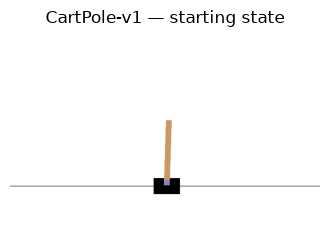

In [4]:
env_preview = gym.make("CartPole-v1", render_mode="rgb_array")
env_preview.reset(seed=RNG_SEED)
frame = env_preview.render()
print("Action space:", env_preview.action_space, " -> 0=push left, 1=push right")
print("Observation space:", env_preview.observation_space)
env_preview.close()

plt.figure(figsize=(4, 3))
plt.imshow(frame)
plt.axis("off")
plt.title("CartPole-v1 — starting state")
plt.show()


Nothing here is discrete — position, velocity, angle and angular velocity are all
real numbers. A plain Q-table has no way to index a continuous value, which is
exactly the problem fuzzy sets solve.


## 2. Task 1 — Fuzzifying the state (2 and 5 fuzzy sets)

Each of the 4 state variables gets its own set of **linguistic terms** — e.g. for
5 sets: *Very Negative, Negative, Zero, Positive, Very Positive*. We use standard
overlapping membership functions so that:

- every value belongs to **1 or 2** neighbouring sets at once (never more, never zero),
- the two outer sets **saturate to 1** past the domain edge (a "shoulder"), so an
  unusually extreme reading still gets a sensible, fully-defined membership instead
  of falling off the edge of the table.

We build both **triangular** (a single peak) and **trapezoidal** (a flat-topped
plateau) versions of the same partition — triangular is used for tasks 1–4 and the
default; trapezoidal is introduced for the comparison in task 5.


In [5]:
# One fuzzy domain per state variable, chosen from CartPole's own physical limits
VAR_NAMES  = ["cart position", "cart velocity", "pole angle", "pole angular velocity"]
VAR_BOUNDS = [(-2.4, 2.4), (-3.0, 3.0), (-0.2094, 0.2094), (-3.0, 3.0)]

LINGUISTIC_LABELS = {
    2: ["Negative", "Positive"],
    5: ["Very Negative", "Negative", "Zero", "Positive", "Very Positive"],
}

def build_partition(lo, hi, n_sets, kind="triangular", plateau_ratio=0.35):
    '''Evenly spaced fuzzy-set centers spanning [lo, hi], plus a plateau half-width
    (0 for triangular, a fraction of the spacing for trapezoidal).'''
    centers = np.linspace(lo, hi, n_sets)
    if n_sets == 1:
        return centers, None
    spacing = centers[1] - centers[0]
    half_plateau = 0.0 if kind == "triangular" else plateau_ratio * spacing / 2.0
    return centers, half_plateau

def memberships(x, centers, hp, n_sets):
    '''Membership degree of value x in every fuzzy set that is not zero.
    Returns {set_index: degree}. Outer sets saturate to 1 beyond the domain edge.'''
    if n_sets == 1:
        return {0: 1.0}
    degs = {}
    for i in range(n_sets):
        c = centers[i]
        if i == 0:                                   # left shoulder
            b = c + hp
            d = centers[1] - hp if hp > 0 else centers[1]
            deg = 1.0 if x <= b else (0.0 if x >= d else (d - x) / (d - b))
        elif i == n_sets - 1:                         # right shoulder
            a = centers[-2] + hp if hp > 0 else centers[-2]
            b = c - hp
            deg = 1.0 if x >= b else (0.0 if x <= a else (x - a) / (b - a))
        else:                                         # interior set
            a = centers[i-1] + hp if hp > 0 else centers[i-1]
            b = c - hp
            cc = c + hp
            d = centers[i+1] - hp if hp > 0 else centers[i+1]
            if b <= x <= cc:
                deg = 1.0
            elif x <= a or x >= d:
                deg = 0.0
            elif x < b:
                deg = (x - a) / (b - a)
            else:
                deg = (d - x) / (d - cc)
        if deg > 1e-9:
            degs[i] = deg
    return degs


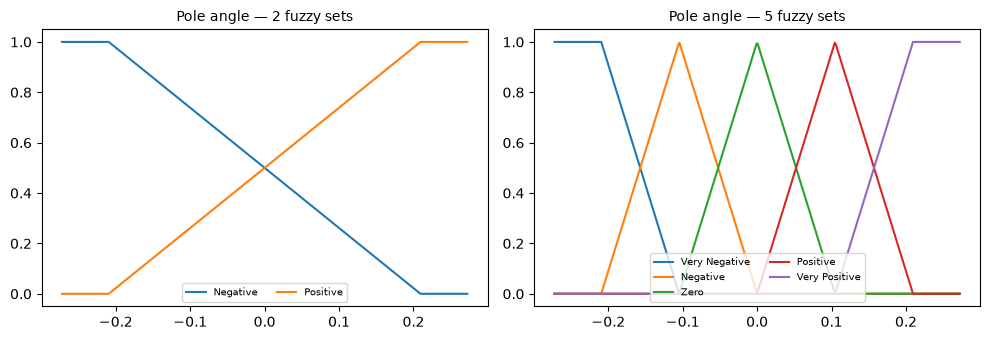

In [6]:
def plot_membership(lo, hi, n_sets, kind, ax, title):
    xs = np.linspace(lo - 0.15 * (hi - lo), hi + 0.15 * (hi - lo), 400)
    centers, hp = build_partition(lo, hi, n_sets, kind)
    labels = LINGUISTIC_LABELS.get(n_sets, [f"Set {i+1}" for i in range(n_sets)])
    for i in range(n_sets):
        ys = [memberships(x, centers, hp, n_sets).get(i, 0.0) for x in xs]
        ax.plot(xs, ys, label=labels[i])
    ax.set_ylim(-0.05, 1.05)
    ax.set_title(title, fontsize=10)
    ax.legend(fontsize=7, loc="lower center", ncol=2)

lo, hi = VAR_BOUNDS[2]   # pole angle, as an example
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
plot_membership(lo, hi, 2, "triangular", axes[0], "Pole angle — 2 fuzzy sets")
plot_membership(lo, hi, 5, "triangular", axes[1], "Pole angle — 5 fuzzy sets")
plt.tight_layout()
plt.show()


With 2 sets the agent only knows *"tilting left"* vs *"tilting right"* — nothing
about how much. With 5 sets it can tell a gentle lean from a genuine fall, which
matters a lot for a task that's fundamentally about fine control. We'll see exactly
how much that matters in the Task 1 comparison below.


## 3. Task 2 — Constructing fuzzy rules

A **rule** picks one linguistic term for every variable at once, e.g. *"pole angle
is Positive AND angular velocity is Zero AND cart position is Zero AND cart
velocity is Negative."* With 4 variables, the full rule base has $n_{\text{sets}}^4$
rules — **16** for 2 sets, **625** for 5 sets.

That sounds like a lot for the 5-set case, but almost all of them stay at zero: a
value only ever activates **1 or 2** neighbouring sets per variable (that's exactly
why we built the membership functions that way), so at most $2^4 = 16$ rules are
ever "active" — i.e. non-zero — at the same instant, no matter how big the full
rule base is. A rule's **firing strength** is the product of its four membership
degrees, normalized so all active rules sum to 1.


In [7]:
def active_rules(per_var_memberships):
    '''Cartesian product of each variable's non-zero fuzzy sets -> list of
    (rule_key, normalized_firing_strength). rule_key is a 4-tuple of set indices.'''
    var_items = [list(d.items()) for d in per_var_memberships]
    raw_rules = []
    for combo in product(*var_items):
        key = tuple(idx for idx, _ in combo)
        strength = 1.0
        for _, deg in combo:
            strength *= deg
        raw_rules.append((key, strength))
    total = sum(s for _, s in raw_rules) + 1e-12
    return [(key, s / total) for key, s in raw_rules]


class FuzzyPartitions:
    '''Holds one membership partition per state variable.'''
    def __init__(self, n_sets, kind):
        self.n_sets, self.kind = n_sets, kind
        self.parts = [build_partition(lo, hi, n_sets, kind) for lo, hi in VAR_BOUNDS]

    def fuzzify(self, state):
        return [memberships(float(x), c, hp, self.n_sets) for x, (c, hp) in zip(state, self.parts)]


# quick sanity check: how many rules actually get touched for a handful of states?
demo_fp = FuzzyPartitions(5, "triangular")
demo_state = (0.1, -0.2, 0.05, 0.3)
demo_rules = active_rules(demo_fp.fuzzify(demo_state))
print(f"Full rule base for 5 sets, 4 variables: {5**4} rules")
print(f"Rules actually active for one example state: {len(demo_rules)}")
print("Their firing strengths sum to:", round(sum(s for _, s in demo_rules), 6))


Full rule base for 5 sets, 4 variables: 625 rules
Rules actually active for one example state: 16
Their firing strengths sum to: 1.0


That's the key trick: however many linguistic terms we use, only a handful of
rules ever fire for any single state, so the algorithm stays fast — the rule base
only *feels* big, it never gets computed in full.


## 4. Tasks 3 & 4 — Fuzzy Q-learning with an ε-greedy policy

Each rule keeps its own tiny Q-table: one value per action, `q_rule[action]`. To
act, we blend every currently-active rule's opinion, weighted by how strongly it's
firing:

$$Q_{\text{global}}(x, a) = \sum_{r \,\in\, \text{active}} \phi_r(x)\, q_r(a)$$

**ε-greedy** on top of that global value is exactly like Part A: with probability
ε take a random action, otherwise take $\arg\max_a Q_{\text{global}}(x,a)$. ε starts
at `1.0` and decays exponentially to `0.01` over training, same as before.

After acting and observing the reward and next state, every rule that fired gets
updated in proportion to how much it contributed to the decision — the same
credit-assignment idea behind the FQL repo we're referencing:

$$\delta = r + \gamma \max_{a'} Q_{\text{global}}(x', a') - Q_{\text{global}}(x, a)
\qquad\qquad
q_r(a) \leftarrow q_r(a) + \alpha\, \delta\, \phi_r(x)$$


In [8]:
def train_fql(n_episodes, n_sets=5, kind="triangular", alpha=0.1, gamma=0.9,
              epsilon_start=1.0, epsilon_min=0.01, seed=RNG_SEED, max_steps=500):
    '''
    Train a Fuzzy Q-learning agent on CartPole-v1.
    Returns the rule Q-table (a dict), the reward earned every episode, and the
    fuzzy partitions used (needed later to fuzzify states again for testing).
    '''
    env = gym.make("CartPole-v1")
    rng = np.random.default_rng(seed)
    fp = FuzzyPartitions(n_sets, kind)
    Q = {}   # rule_key (4-tuple) -> np.array([q_left, q_right])

    def get_q(key):
        if key not in Q:
            Q[key] = np.zeros(2)
        return Q[key]

    decay_rate = (epsilon_min / epsilon_start) ** (1.0 / n_episodes)
    epsilon = epsilon_start
    episode_rewards = np.zeros(n_episodes)

    for ep in range(n_episodes):
        state, _ = env.reset(seed=int(rng.integers(1_000_000_000)))
        rules = active_rules(fp.fuzzify(state))
        done, steps, total_reward = False, 0, 0.0

        while not done and steps < max_steps:
            q_global = np.zeros(2)
            for key, phi in rules:
                q_global += phi * get_q(key)

            if rng.random() < epsilon:
                action = int(rng.integers(2))
            else:
                action = int(np.argmax(q_global))

            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            steps += 1

            if done:
                v_next, next_rules = 0.0, None
            else:
                next_rules = active_rules(fp.fuzzify(next_state))
                q_next = np.zeros(2)
                for key, phi in next_rules:
                    q_next += phi * get_q(key)
                v_next = q_next.max()

            td_error = reward + gamma * v_next - q_global[action]
            for key, phi in rules:                       # credit assignment
                get_q(key)[action] += alpha * td_error * phi

            state = next_state
            total_reward += reward
            rules = next_rules if next_rules is not None else rules

        episode_rewards[ep] = total_reward
        epsilon = max(epsilon_min, epsilon * decay_rate)

    env.close()
    return Q, episode_rewards, fp


def test_fql(Q, fp, n_episodes=100, seed=123, max_steps=500):
    '''Greedy (epsilon=0) evaluation for n_episodes, returns the reward of each.'''
    env = gym.make("CartPole-v1")
    rng = np.random.default_rng(seed)
    rewards = np.zeros(n_episodes)

    for ep in range(n_episodes):
        state, _ = env.reset(seed=int(rng.integers(1_000_000_000)))
        done, steps, total_reward = False, 0, 0.0
        while not done and steps < max_steps:
            rules = active_rules(fp.fuzzify(state))
            q_global = np.zeros(2)
            for key, phi in rules:
                if key in Q:
                    q_global += phi * Q[key]
            action = int(np.argmax(q_global))
            state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            steps += 1
            total_reward += reward
        rewards[ep] = total_reward

    env.close()
    return rewards

def moving_average(x, window=50):
    window = min(window, len(x))
    return np.convolve(x, np.ones(window) / window, mode="valid")


This is the whole algorithm: fuzzify → blend rule opinions into one global
Q-value per action → act ε-greedily → spread the TD update back across whichever
rules actually fired, weighted by how much each one fired.


## 5. Baseline run

We'll train every configuration for **800 episodes** and evaluate the frozen,
greedy policy on **100 test episodes** — the same train/test split used in Part A.
Our baseline: **5 fuzzy sets, triangular membership, α = 0.1, γ = 0.9**.


In [9]:
results = {}   # config name -> dict(Q, rewards, fp, test_rewards, cfg)

def run_config(name, **cfg):
    Q, rewards, fp = train_fql(800, **cfg)
    test_rewards = test_fql(Q, fp, n_episodes=100)
    results[name] = dict(Q=Q, rewards=rewards, fp=fp, test_rewards=test_rewards, cfg=cfg)
    print(f"{name:22s} train (last 100 ep): {rewards[-100:].mean():6.1f}   "
          f"test avg reward: {test_rewards.mean():6.1f}   "
          f"test success (>=195): {(test_rewards >= 195).mean()*100:5.1f}%")
    return results[name]

baseline = run_config("baseline", n_sets=5, kind="triangular", alpha=0.1, gamma=0.9)


baseline               train (last 100 ep):  218.3   test avg reward:  154.1   test success (>=195):  14.0%


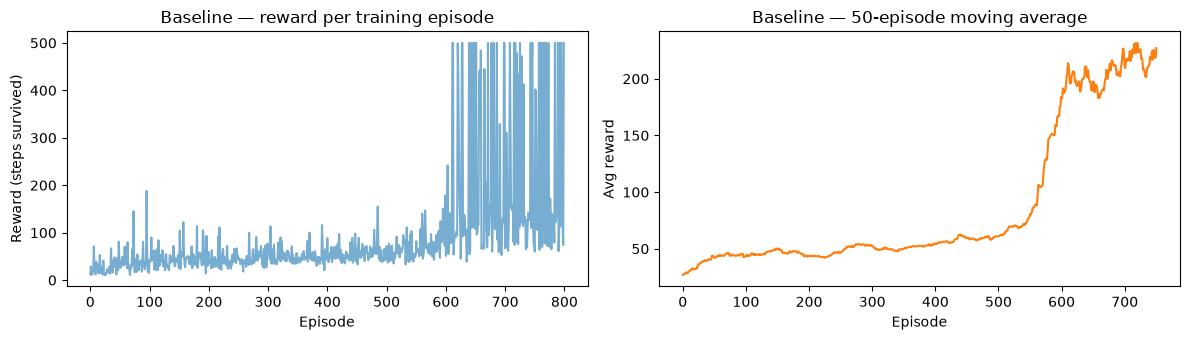

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
axes[0].plot(baseline["rewards"], color="tab:blue", alpha=0.6)
axes[0].set_title("Baseline — reward per training episode")
axes[0].set_xlabel("Episode"); axes[0].set_ylabel("Reward (steps survived)")

axes[1].plot(moving_average(baseline["rewards"]), color="tab:orange")
axes[1].set_title("Baseline — 50-episode moving average")
axes[1].set_xlabel("Episode"); axes[1].set_ylabel("Avg reward")
plt.tight_layout()
plt.show()


Early on the pole falls almost immediately (reward near 20–40). Around episode
500–600 the moving average takes off, and by the end the agent is regularly
surviving several hundred steps. Fuzzy Q-learning has no target network or replay
buffer, so don't expect a perfectly smooth climb — some wobble along the way is
completely normal for this algorithm, not a bug.


## 6. Task 1 — Comparing 2 vs 5 fuzzy sets

Same everything else as the baseline (triangular, α = 0.1, γ = 0.9) — only the
number of linguistic terms per variable changes.


2 fuzzy sets           train (last 100 ep):   81.7   test avg reward:    9.4   test success (>=195):   0.0%


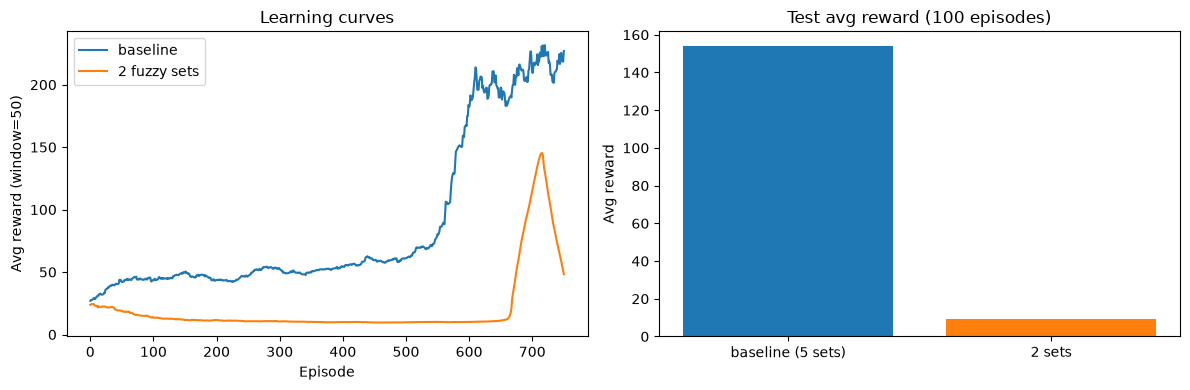

In [11]:
run_config("2 fuzzy sets", n_sets=2, kind="triangular", alpha=0.1, gamma=0.9)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for name in ["baseline", "2 fuzzy sets"]:
    axes[0].plot(moving_average(results[name]["rewards"]), label=name)
axes[0].set_title("Learning curves"); axes[0].set_xlabel("Episode")
axes[0].set_ylabel("Avg reward (window=50)"); axes[0].legend()

names = ["baseline (5 sets)", "2 sets"]
vals = [results["baseline"]["test_rewards"].mean(), results["2 fuzzy sets"]["test_rewards"].mean()]
axes[1].bar(names, vals, color=["tab:blue", "tab:orange"])
axes[1].set_title("Test avg reward (100 episodes)"); axes[1].set_ylabel("Avg reward")
plt.tight_layout()
plt.show()


5 fuzzy sets clearly wins. With only 2 sets ("tilting left" / "tilting right") the
agent can't tell a gentle lean from an emergency, so it keeps over- or
under-correcting — you can see it barely improve for most of training, with only
a brief, unstable improvement late on. Finer linguistic resolution isn't just
nicer, it's necessary for a task that lives or dies on small corrections.


## 7. Task 5 — Comparing triangular vs trapezoidal membership functions

Same as baseline (5 sets, α = 0.1, γ = 0.9) — only the membership function shape
changes to trapezoidal (each set gets a small flat-topped plateau instead of a
single peak).


trapezoidal            train (last 100 ep):   36.6   test avg reward:   36.8   test success (>=195):   0.0%


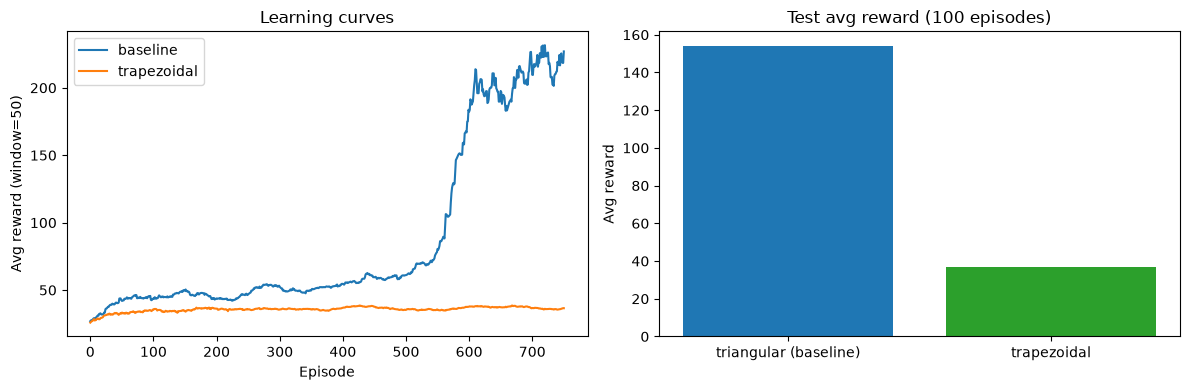

In [12]:
run_config("trapezoidal", n_sets=5, kind="trapezoidal", alpha=0.1, gamma=0.9)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for name in ["baseline", "trapezoidal"]:
    axes[0].plot(moving_average(results[name]["rewards"]), label=name)
axes[0].set_title("Learning curves"); axes[0].set_xlabel("Episode")
axes[0].set_ylabel("Avg reward (window=50)"); axes[0].legend()

names = ["triangular (baseline)", "trapezoidal"]
vals = [results["baseline"]["test_rewards"].mean(), results["trapezoidal"]["test_rewards"].mean()]
axes[1].bar(names, vals, color=["tab:blue", "tab:green"])
axes[1].set_title("Test avg reward (100 episodes)"); axes[1].set_ylabel("Avg reward")
plt.tight_layout()
plt.show()


Triangular membership functions learn noticeably faster here. Inside a
trapezoid's flat top, every nearby state looks *identically* "fully Zero" (or
fully whatever term), so the agent loses some of the fine gradient it needs to
tell close-but-different situations apart. A single sharp peak, by contrast, gives
every state a slightly different blend of neighbouring sets — more useful signal
for the same 800 episodes of practice.


## 8. Task 6 — Comparing learning rates (α = 0.01, 0.05, 0.1)

Same as baseline (5 sets, triangular, γ = 0.9) — only α changes. α = 0.1 *is* the
baseline, so we only need to train the other two.


alpha=0.01             train (last 100 ep):    9.3   test avg reward:    9.2   test success (>=195):   0.0%
alpha=0.05             train (last 100 ep):   51.7   test avg reward:   56.7   test success (>=195):   0.0%


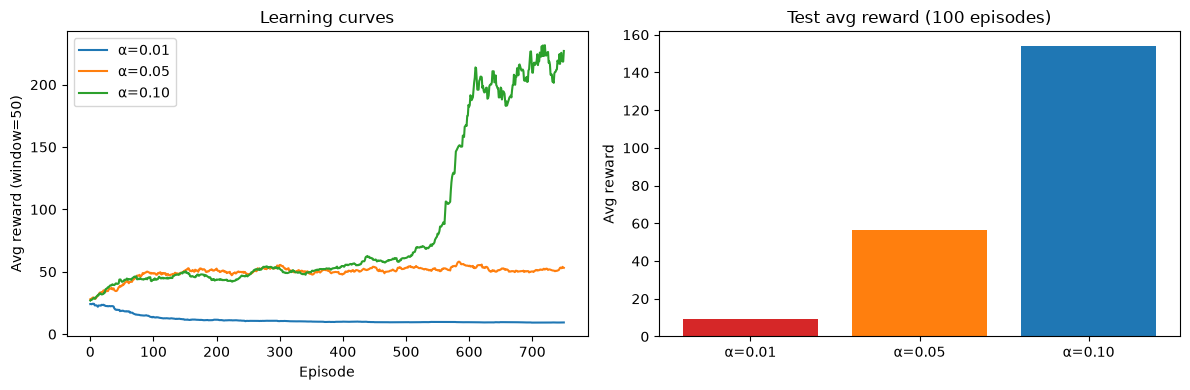

In [13]:
run_config("alpha=0.01", n_sets=5, kind="triangular", alpha=0.01, gamma=0.9)
run_config("alpha=0.05", n_sets=5, kind="triangular", alpha=0.05, gamma=0.9)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for name, lbl in [("alpha=0.01", "α=0.01"), ("alpha=0.05", "α=0.05"), ("baseline", "α=0.10")]:
    axes[0].plot(moving_average(results[name]["rewards"]), label=lbl)
axes[0].set_title("Learning curves"); axes[0].set_xlabel("Episode")
axes[0].set_ylabel("Avg reward (window=50)"); axes[0].legend()

names = ["α=0.01", "α=0.05", "α=0.10"]
vals = [results["alpha=0.01"]["test_rewards"].mean(), results["alpha=0.05"]["test_rewards"].mean(),
        results["baseline"]["test_rewards"].mean()]
axes[1].bar(names, vals, color=["tab:red", "tab:orange", "tab:blue"])
axes[1].set_title("Test avg reward (100 episodes)"); axes[1].set_ylabel("Avg reward")
plt.tight_layout()
plt.show()


A clean staircase: α = 0.01 barely updates the Q-values at all in 800 episodes —
it's still close to where it started. α = 0.05 makes visible progress. α = 0.1 is
the only one fast enough to actually take off within this budget. That's the
classic learning-rate trade-off: too small and you simply haven't learned enough
yet; a Fuzzy Q-learning table like this one can typically afford a fairly high α
because each update is already softened by being spread across several rules.


## 9. Task 7 — Comparing discount factors (γ = 0.5, 0.9)

Same as baseline (5 sets, triangular, α = 0.1) — only γ changes. γ = 0.9 *is* the
baseline, so we only need to train γ = 0.5.


gamma=0.5              train (last 100 ep):   57.6   test avg reward:   56.0   test success (>=195):   0.0%


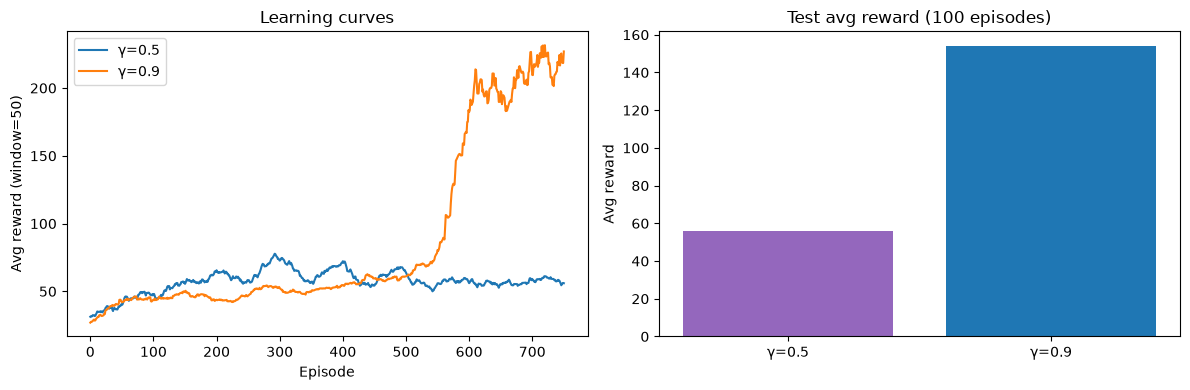

In [14]:
run_config("gamma=0.5", n_sets=5, kind="triangular", alpha=0.1, gamma=0.5)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for name, lbl in [("gamma=0.5", "γ=0.5"), ("baseline", "γ=0.9")]:
    axes[0].plot(moving_average(results[name]["rewards"]), label=lbl)
axes[0].set_title("Learning curves"); axes[0].set_xlabel("Episode")
axes[0].set_ylabel("Avg reward (window=50)"); axes[0].legend()

names = ["γ=0.5", "γ=0.9"]
vals = [results["gamma=0.5"]["test_rewards"].mean(), results["baseline"]["test_rewards"].mean()]
axes[1].bar(names, vals, color=["tab:purple", "tab:blue"])
axes[1].set_title("Test avg reward (100 episodes)"); axes[1].set_ylabel("Avg reward")
plt.tight_layout()
plt.show()


γ = 0.9 pulls well ahead. Balancing a pole is entirely about *staying up in the
future* — a reward that only shows up if you don't fall over the next several
hundred steps. A low discount factor (γ = 0.5) makes the agent almost short-sighted,
barely valuing anything more than a couple of steps ahead, which is exactly the
wrong instinct for a task this dependent on long-horizon stability.


## 10. Bonus — what does the learned policy actually look like?

Not part of the seven tasks, but a nice way to see the controller directly: fix the
cart at the centre, standing still, and sweep pole angle against pole angular
velocity. Every point on this grid is coloured by whichever action the baseline
agent's fuzzy rules vote for.


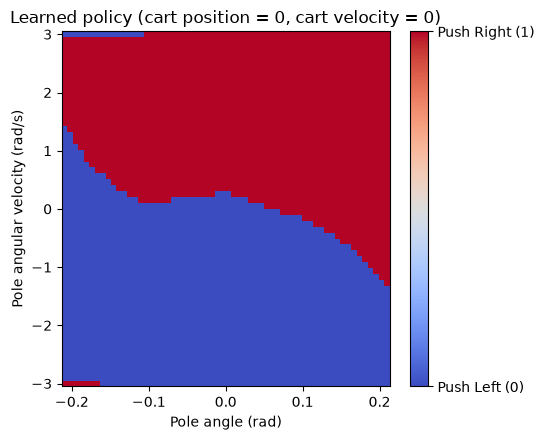

In [15]:
Q_base, fp_base = baseline["Q"], baseline["fp"]

lo_a, hi_a = VAR_BOUNDS[2]   # pole angle
lo_w, hi_w = VAR_BOUNDS[3]   # pole angular velocity
angles = np.linspace(lo_a, hi_a, 60)
avels  = np.linspace(lo_w, hi_w, 60)
policy_grid = np.zeros((60, 60))

for iy, w in enumerate(avels):
    for ix, a in enumerate(angles):
        rules = active_rules(fp_base.fuzzify((0.0, 0.0, a, w)))
        q_global = np.zeros(2)
        for key, phi in rules:
            if key in Q_base:
                q_global += phi * Q_base[key]
        policy_grid[iy, ix] = np.argmax(q_global)

plt.figure(figsize=(5.5, 4.5))
plt.pcolormesh(angles, avels, policy_grid, cmap="coolwarm", shading="auto")
plt.xlabel("Pole angle (rad)")
plt.ylabel("Pole angular velocity (rad/s)")
plt.title("Learned policy (cart position = 0, cart velocity = 0)")
cbar = plt.colorbar(ticks=[0, 1])
cbar.ax.set_yticklabels(["Push Left (0)", "Push Right (1)"])
plt.tight_layout()
plt.show()


That diagonal split is textbook bang-bang pole-balancing control: whenever the
pole is tilting *and/or* rotating to the right, push right to catch it; tilting or
rotating left, push left. The boundary is a clean diagonal rather than a plain
cross, which makes sense — a small tilt with fast rotation deserves the same
correction as a big tilt with no rotation.


## 11. Bonus — watching the trained agent balance

A greedy rollout (ε = 0) of the baseline agent, frame by frame.


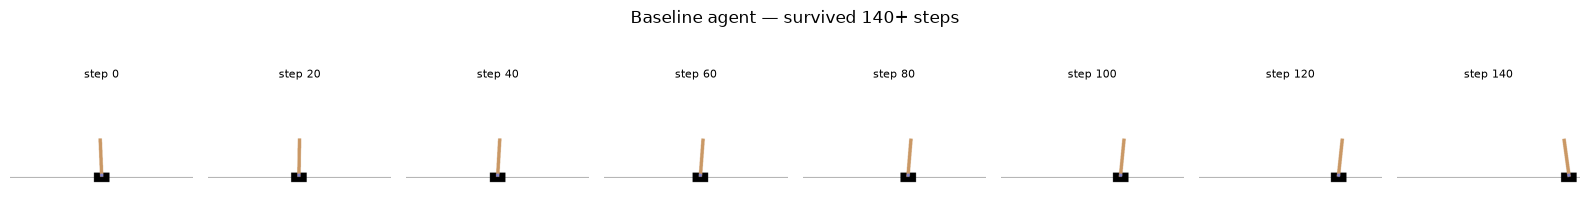

In [16]:
def rollout_frames(Q, fp, max_steps=140, seed=1):
    env = gym.make("CartPole-v1", render_mode="rgb_array")
    state, _ = env.reset(seed=seed)
    frames = [env.render()]
    done, steps = False, 0
    while not done and steps < max_steps:
        rules = active_rules(fp.fuzzify(state))
        q_global = np.zeros(2)
        for key, phi in rules:
            if key in Q:
                q_global += phi * Q[key]
        action = int(np.argmax(q_global))
        state, reward, terminated, truncated, _ = env.step(action)
        frames.append(env.render())
        done = terminated or truncated
        steps += 1
    env.close()
    return frames, steps

frames, steps_survived = rollout_frames(Q_base, fp_base)
show_idx = np.linspace(0, len(frames) - 1, 8).astype(int)

fig, axes = plt.subplots(1, len(show_idx), figsize=(2.0 * len(show_idx), 2.2))
for ax, i in zip(axes, show_idx):
    ax.imshow(frames[i]); ax.axis("off"); ax.set_title(f"step {i}", fontsize=8)
plt.suptitle(f"Baseline agent — survived {steps_survived}+ steps", y=1.05)
plt.tight_layout()
plt.show()


The pole barely drifts across this whole stretch — visibly the same steady,
back-and-forth balancing behaviour the policy heatmap above predicted.


## 12. Summary


In [17]:
summary_rows = []
for name, res in results.items():
    summary_rows.append({
        "Configuration": name,
        "Fuzzy sets": res["cfg"]["n_sets"],
        "MF shape": res["cfg"]["kind"],
        "Alpha": res["cfg"]["alpha"],
        "Gamma": res["cfg"]["gamma"],
        "Train avg (last 100 ep)": round(res["rewards"][-100:].mean(), 1),
        "Test avg reward": round(res["test_rewards"].mean(), 1),
        "Test success rate (%)": round((res["test_rewards"] >= 195).mean() * 100, 1),
    })
summary_df = pd.DataFrame(summary_rows)
display(summary_df)


,Configuration,Fuzzy sets,MF shape,Alpha,Gamma,Train avg (last 100 ep),Test avg reward,Test success rate (%)
0,baseline,5,triangular,0.10,0.9,218.3,154.1,14.0
1,2 fuzzy sets,2,triangular,0.10,0.9,81.7,9.4,0.0
2,trapezoidal,5,trapezoidal,0.10,0.9,36.6,36.8,0.0
3,alpha=0.01,5,triangular,0.01,0.9,9.3,9.2,0.0
4,alpha=0.05,5,triangular,0.05,0.9,51.7,56.7,0.0
5,gamma=0.5,5,triangular,0.10,0.5,57.6,56.0,0.0


## Conclusion

- **Fuzzy sets (Task 1):** 5 linguistic terms per variable beat 2 by a wide margin
  — coarse fuzzification throws away exactly the fine distinctions a balancing
  task depends on.
- **Membership shape (Task 5):** triangular functions out-learned trapezoidal ones
  in the same training budget — the flat plateau of a trapezoid blurs together
  states that a sharp triangular peak would tell apart.
- **Learning rate (Task 6):** α = 0.1 was the only value fast enough to converge
  in 800 episodes; α = 0.01 barely moved. Because FQL already spreads each update
  across several rules, a higher α than you might use in plain tabular Q-learning
  is often perfectly stable.
- **Discount factor (Task 7):** γ = 0.9 comfortably beat γ = 0.5 — pole-balancing
  is a long-horizon task, and a myopic agent simply can't plan far enough ahead to
  stay up.
- Across every comparison, the same **fuzzify → blend rule opinions into a global
  Q-value → act ε-greedily → credit-weighted update** loop (Tasks 2–4) was the
  one constant — only ever one dial was turned at a time.
